# Notebook 30 — Domain-Robustness Experiments for 3-Dataset VPN Detection

## Root cause
USBVPN dominates training (78% of flows) and `direction_balance_*` features encode
dataset identity (domain-detector AUC ≈ 1.0). The 3-dataset model learns USBVPN-specific
patterns and **loses** VPN detection on ISCX and VNAT.

## Experiments
| ID | Experiment | Hypothesis |
|----|-----------|------------|
| Diag | Domain fingerprinting | Quantify how well each feature identifies the source dataset |
| A | Drop direction features | Removing the 2 most leaky features restores cross-domain VPN signal |
| B | Dataset-balanced sampling | Capping USBVPN to match ISCX+VNAT prevents domination |
| C | Combined (A + B) | Both fixes together |
| D | Expanded feature set | Adding IAT timing + balance → more signal without more leakage |
| E | Adversarial feature selection | Iteratively remove features until domain-detector AUC ≤ 0.70 |


In [1]:
# ── Cell 0: Imports & Data Loading ──────────────────────────────────────────
%matplotlib inline

import sys, os, json, warnings, time
warnings.filterwarnings('ignore')

_root = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
if _root not in sys.path:
    sys.path.insert(0, _root)
os.chdir(_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import LabelEncoder, QuantileTransformer

from src.utils.paths import load_paths
from src.utils.logging import setup_logger
from src.pipeline.data_preparation import load_and_prepare_data
from src.pipeline.feature_pipeline import FeaturePipeline, COMPACT_FEATURES, DIRECTION_FEATURES
from src.features.extract import extract_features_from_flows, load_feature_config
from src.models.train_balanced_bagging_ensemble import run_balanced_bagging
from src.optimization.dataset_adversarial_feature_selection import train_dataset_detector

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

paths = load_paths()
logger = setup_logger(level='INFO')
SEED = 42
EXPERIMENTS_DIR = paths.artifacts_dir / 'experiments'
EXPERIMENTS_DIR.mkdir(parents=True, exist_ok=True)

# Load 3-dataset pool
df_all = load_and_prepare_data(vnat_only=False)

print(f'Total pool: {df_all.shape}')
print()
print('Flows per dataset × split:')
print(pd.crosstab(df_all['split'], df_all['dataset']))
print()
print('Label distribution:')
print(pd.crosstab(df_all['dataset'], df_all['label'], margins=True))
print()
# Show dataset dominance
train_counts = df_all[df_all['split'] == 'train']['dataset'].value_counts()
print('Training set composition:')
for ds, n in train_counts.items():
    print(f'  {ds}: {n:,} ({100*n/train_counts.sum():.1f}%)')


2026-03-31 19:06:17 | INFO | ai-vpn-firewall | Loading VNAT (PCAP-based)...
2026-03-31 19:06:17 | INFO | ai-vpn-firewall | [VNAT] Loaded features.parquet (33711 flows, splits already assigned)
2026-03-31 19:06:17 | INFO | ai-vpn-firewall | Loading ISCX (PCAP-based)...
2026-03-31 19:06:17 | INFO | ai-vpn-firewall | [ISCX] Loaded features.parquet (76687 flows, splits already assigned)
2026-03-31 19:06:17 | INFO | ai-vpn-firewall | Loading USBVPN (JSON-based)...
2026-03-31 19:06:17 | INFO | ai-vpn-firewall | Removing exact duplicate flows across feature columns...
2026-03-31 19:06:17 | INFO | ai-vpn-firewall | Ensuring numeric dtypes for feature columns...
2026-03-31 19:06:18 | INFO | ai-vpn-firewall | ✓ All feature columns successfully converted to numeric dtypes
2026-03-31 19:06:18 | INFO | ai-vpn-firewall | Removed 5750 duplicate flows (7.92%)
2026-03-31 19:06:18 | INFO | ai-vpn-firewall | Metadata columns present for analysis only: ['source_capture_id', 'source_file']
2026-03-31 19:06

In [2]:
# ── Cell 1: Load tuned hyperparameters ─────────────────────────────────────

with open(paths.artifacts_dir / 'optuna_xgboost_firewall_best_params.json') as f:
    xgb_params = json.load(f)
xgb_params.update({
    'objective': 'binary:logistic', 'eval_metric': 'logloss',
    'booster': 'gbtree', 'tree_method': 'hist',
    'n_estimators': 1000, 'random_state': 42, 'n_jobs': 1,
    'early_stopping_rounds': 50,
})

with open(paths.artifacts_dir / 'optuna_catboost_firewall_best_params.json') as f:
    cat_params = json.load(f)
cat_params.update({
    'iterations': 1000, 'random_seed': 42, 'thread_count': 1,
    'verbose': False, 'allow_writing_files': False,
    'early_stopping_rounds': 150,
})

with open(paths.artifacts_dir / 'optuna_lgbm_firewall_best_params.json') as f:
    lgbm_params = json.load(f)
lgbm_params.update({
    'objective': 'binary', 'metric': 'binary_logloss',
    'boosting_type': 'gbdt', 'n_estimators': 1000,
    'verbose': -1, 'random_state': 42, 'n_jobs': 1,
})

print('Hyperparameters loaded.')
print(f'  XGB:  lr={xgb_params["learning_rate"]:.4f}, depth={xgb_params["max_depth"]}')
print(f'  LGBM: lr={lgbm_params["learning_rate"]:.4f}, depth={lgbm_params["max_depth"]}')
print(f'  Cat:  lr={cat_params["learning_rate"]:.4f}, depth={cat_params["depth"]}')


Hyperparameters loaded.
  XGB:  lr=0.1025, depth=5
  LGBM: lr=0.1432, depth=5
  Cat:  lr=0.0988, depth=4


In [3]:
# ── Cell 2: Experiment helper ──────────────────────────────────────────────

def run_experiment(
    name: str,
    df_pool: pd.DataFrame,
    feature_cols: list,
    output_subdir: str,
    *,
    skip_pipeline_transform: bool = False,
) -> dict:
    """
    Train a balanced bagging ensemble and return summary metrics.

    If skip_pipeline_transform=True, feature_cols are used directly on df_pool
    (useful when features have already been scaled or are non-standard).
    """
    out_dir = EXPERIMENTS_DIR / output_subdir
    out_dir.mkdir(parents=True, exist_ok=True)

    t0 = time.time()
    print(f'\n{"="*72}')
    print(f'  EXPERIMENT: {name}')
    print(f'  Features ({len(feature_cols)}): {feature_cols}')
    print(f'  Pool size: {len(df_pool):,} flows')
    print(f'{"="*72}')

    if not skip_pipeline_transform:
        # Fit FeaturePipeline on training split only
        df_train_raw = df_pool[df_pool['split'] == 'train'].copy()
        pipe = FeaturePipeline().fit(df_train_raw)
        df_transformed = pipe.transform(df_pool)
        # Carry metadata columns
        for col in ['label', 'split', 'capture_id', 'dataset', 'flow_id',
                     'source_file', 'source_capture_id']:
            if col in df_pool.columns:
                df_transformed[col] = df_pool[col].values
        model_feature_cols = pipe.model_feature_names()
        # Intersect with requested feature_cols
        model_feature_cols = [c for c in model_feature_cols if c in feature_cols]
    else:
        df_transformed = df_pool.copy()
        model_feature_cols = feature_cols

    # Verify columns exist
    missing = [c for c in model_feature_cols if c not in df_transformed.columns]
    if missing:
        raise ValueError(f'Missing feature columns: {missing}')

    results = run_balanced_bagging(
        df=df_transformed,
        label_col='label',
        group_col='capture_id',
        dataset_col='dataset',
        split_col='split',
        bags_per_family=3,
        majority_ratio=1.0,
        target_fprs='0.0,0.001,0.005,0.01',
        seed=SEED,
        output_dir=str(out_dir),
        model_types=['xgb', 'lgbm', 'cat'],
        feature_cols=model_feature_cols,
        weight_xgb=1.0, weight_lgbm=1.0, weight_cat=1.0,
        xgb_params=xgb_params,
        cat_params=cat_params,
        lgbm_params=lgbm_params,
    )

    elapsed = time.time() - t0

    # Extract key metrics
    def safe_metric(section, split_key, metric):
        try:
            return results[section][split_key][metric]
        except (KeyError, TypeError):
            return float('nan')

    summary = {
        'experiment': name,
        'n_features': len(model_feature_cols),
        'features': model_feature_cols,
        'train_flows': int((df_pool['split'] == 'train').sum()),
        'val_auc': safe_metric('isotonic', 'val', 'auc'),
        'val_pr_auc': safe_metric('isotonic', 'val', 'pr_auc'),
        'test_auc': safe_metric('isotonic', 'test_overall', 'auc'),
        'test_pr_auc': safe_metric('isotonic', 'test_overall', 'pr_auc'),
        'elapsed_s': elapsed,
    }

    # Per-dataset test AUC
    for ds in ['iscx', 'vnat', 'usbvpn']:
        summary[f'test_auc_{ds}'] = safe_metric('isotonic', f'test_{ds}', 'auc')
        summary[f'test_pr_auc_{ds}'] = safe_metric('isotonic', f'test_{ds}', 'pr_auc')

    # FPR=0 recall (strict)
    for ds_key in ['test_overall', 'test_iscx', 'test_vnat', 'test_usbvpn']:
        fpr0 = safe_metric('isotonic', ds_key, 'fpr_0.0')
        if isinstance(fpr0, dict):
            summary[f'recall_fpr0_{ds_key}'] = fpr0.get('recall', float('nan'))
        else:
            summary[f'recall_fpr0_{ds_key}'] = float('nan')

    # Save summary alongside metrics
    with open(out_dir / 'experiment_summary.json', 'w') as f:
        json.dump(summary, f, indent=2, default=str)

    print(f'\n  Results ({name}): elapsed={elapsed:.1f}s')
    print(f'    Val  AUC={summary["val_auc"]:.4f}  PR-AUC={summary["val_pr_auc"]:.4f}')
    print(f'    Test AUC={summary["test_auc"]:.4f}  PR-AUC={summary["test_pr_auc"]:.4f}')
    for ds in ['iscx', 'vnat', 'usbvpn']:
        v = summary.get(f'test_auc_{ds}', float('nan'))
        print(f'    Test AUC [{ds:>6s}] = {v:.4f}')

    return summary

all_summaries = []


## Section 1 — Domain Fingerprinting Diagnostic

Train a dataset-identity classifier (XGBoost multiclass) to predict
which dataset a flow comes from using only compact features.

If AUC ≈ 1.0, the features encode dataset identity → domain leakage.


In [4]:
# ── Cell 3: Domain fingerprinting diagnostic ────────────────────────────────

df_train = df_all[df_all['split'] == 'train'].copy()
df_val = df_all[df_all['split'] == 'val'].copy()

le = LabelEncoder()
le.fit(df_all['dataset'])
y_train_ds = le.transform(df_train['dataset'])
y_val_ds = le.transform(df_val['dataset'])
print(f'Dataset classes: {list(le.classes_)}')

# Feature sets to test
ALL_COMPACT = [c for c in COMPACT_FEATURES if c in df_train.columns]
NO_DIRECTION = [c for c in ALL_COMPACT if c not in DIRECTION_FEATURES]
DIRECTION_ONLY = [c for c in ALL_COMPACT if c in DIRECTION_FEATURES]

feature_sets = {
    'All 7 compact': ALL_COMPACT,
    '5 (no direction)': NO_DIRECTION,
    '2 (direction only)': DIRECTION_ONLY,
}

diag_results = []
diag_models = {}

for set_name, feats in feature_sets.items():
    X_tr = df_train[feats].values
    X_va = df_val[feats].values
    model, auc = train_dataset_detector(X_tr, y_train_ds, X_va, y_val_ds)
    diag_results.append({'Feature Set': set_name, 'N Features': len(feats),
                         'Domain AUC': auc, 'Features': feats})
    diag_models[set_name] = model
    print(f'  {set_name:25s} → Domain AUC = {auc:.4f}')

print()
diag_df = pd.DataFrame(diag_results)
print(diag_df[['Feature Set', 'N Features', 'Domain AUC']].to_string(index=False))


Dataset classes: ['iscx', 'usbvpn', 'vnat']
  All 7 compact             → Domain AUC = 0.9998
  5 (no direction)          → Domain AUC = 0.9778
  2 (direction only)        → Domain AUC = 0.9978

       Feature Set  N Features  Domain AUC
     All 7 compact           7    0.999778
  5 (no direction)           5    0.977760
2 (direction only)           2    0.997803


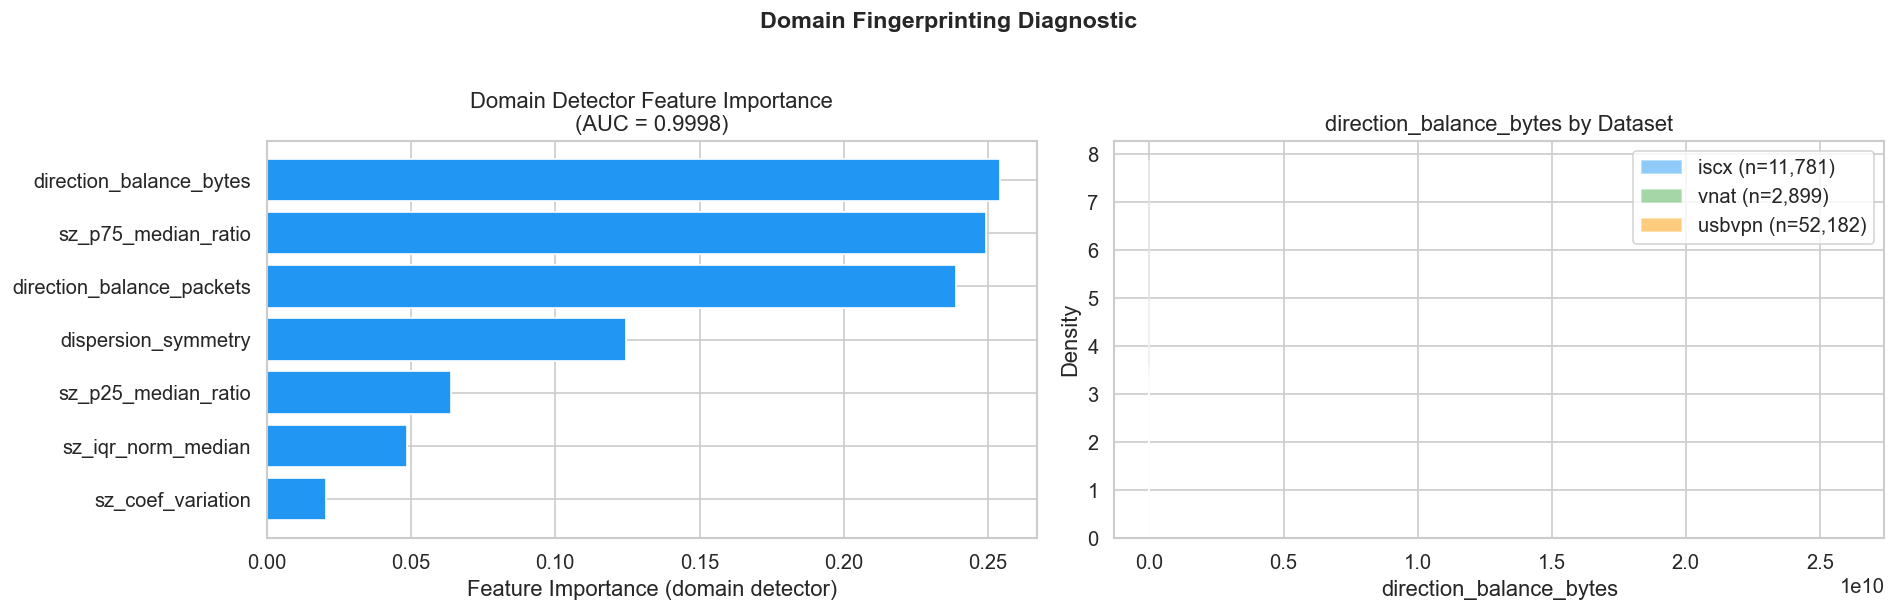

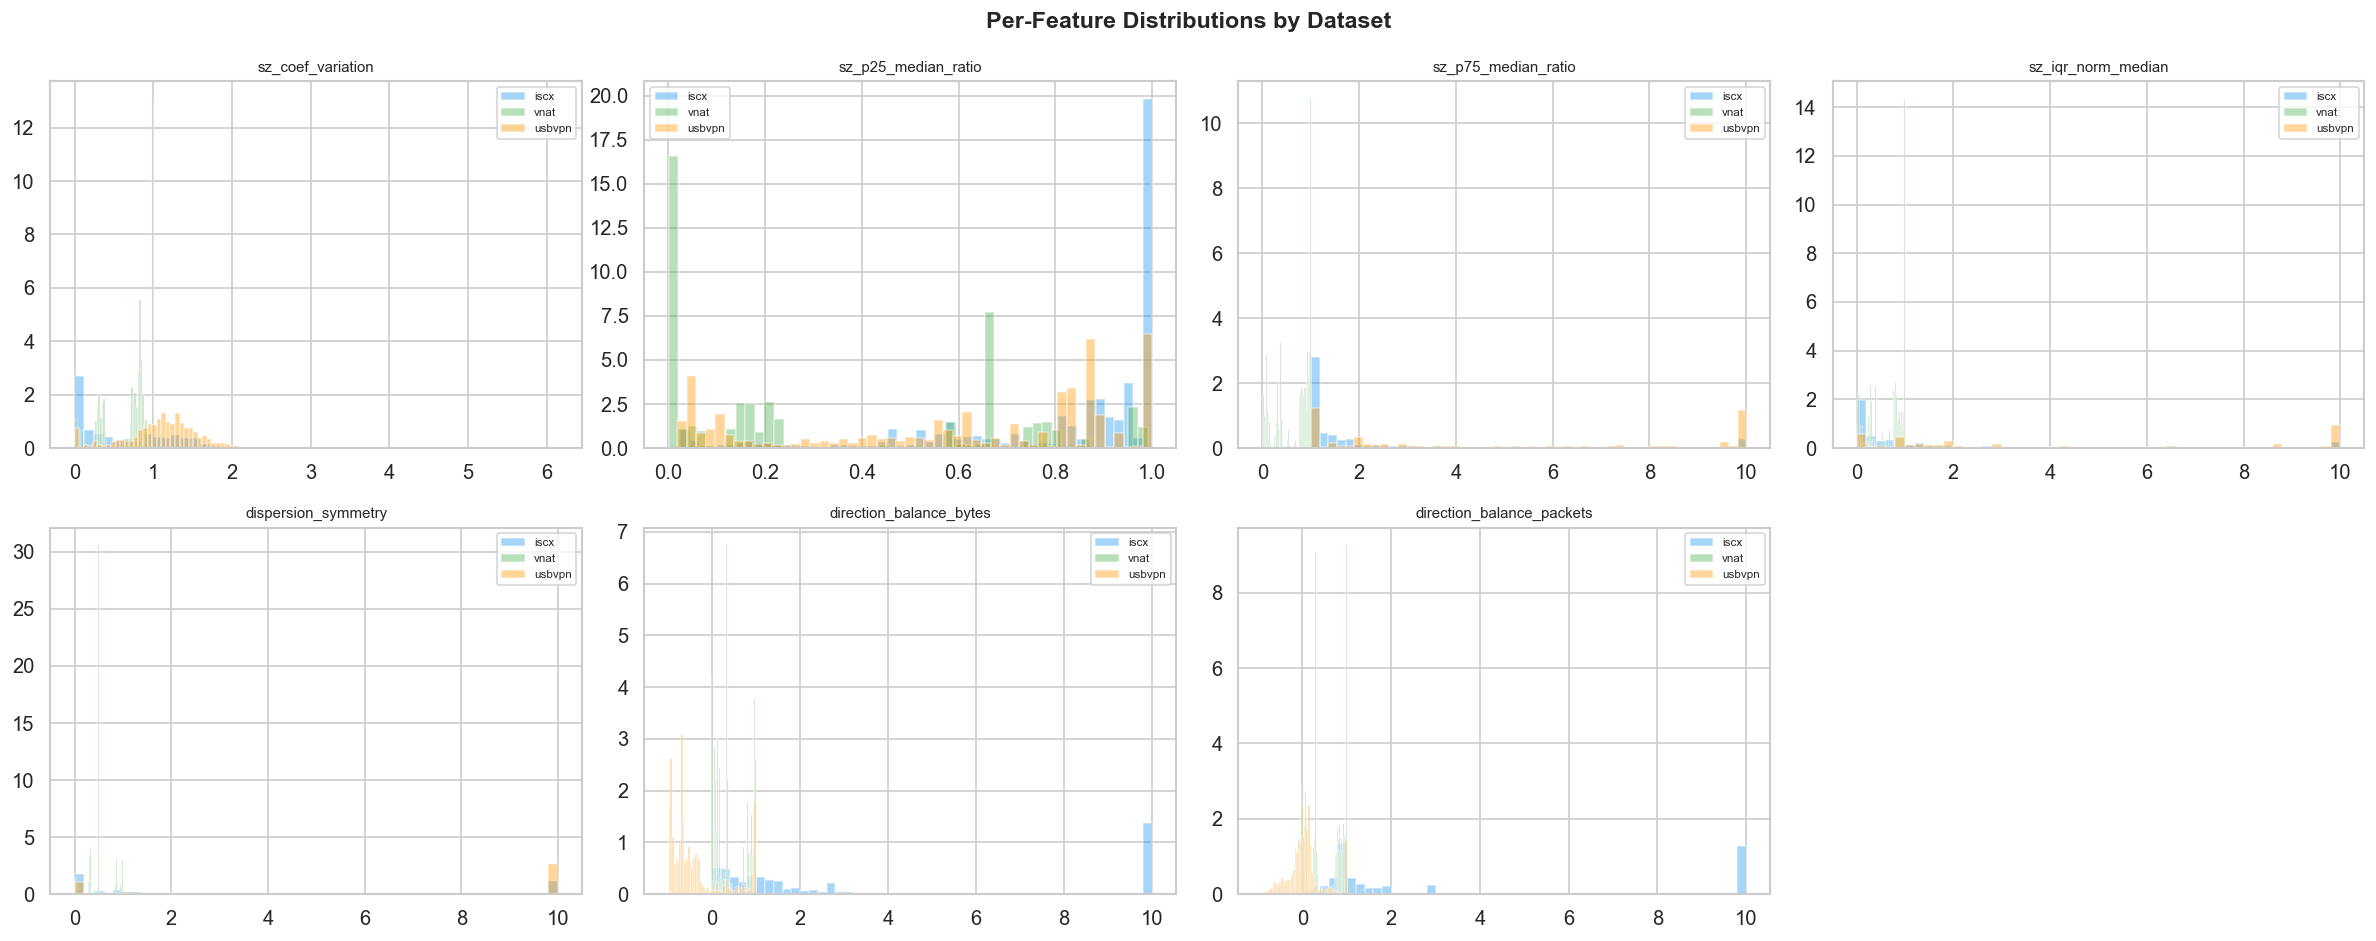

In [5]:
# ── Cell 4: Feature importance & distribution plots ─────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: feature importances from the "All 7 compact" detector
ax = axes[0]
model_all = diag_models['All 7 compact']
imp = model_all.feature_importances_
feat_names = ALL_COMPACT
order = np.argsort(imp)
ax.barh([feat_names[i] for i in order], imp[order], color='#2196F3')
ax.set_xlabel('Feature Importance (domain detector)')
ax.set_title(f'Domain Detector Feature Importance\n(AUC = {diag_results[0]["Domain AUC"]:.4f})')

# Right: direction_balance_bytes distribution per dataset
ax = axes[1]
for ds, color in [('iscx', '#2196F3'), ('vnat', '#4CAF50'), ('usbvpn', '#FF9800')]:
    subset = df_all[df_all['dataset'] == ds]['direction_balance_bytes']
    ax.hist(subset.values, bins=60, alpha=0.5, density=True, label=f'{ds} (n={len(subset):,})', color=color)
ax.set_xlabel('direction_balance_bytes')
ax.set_ylabel('Density')
ax.set_title('direction_balance_bytes by Dataset')
ax.legend()

plt.suptitle('Domain Fingerprinting Diagnostic', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(EXPERIMENTS_DIR / 'diagnostic_domain_fingerprinting.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-feature KDE for all 7 features
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for i, feat in enumerate(ALL_COMPACT):
    ax = axes.ravel()[i]
    for ds, color in [('iscx', '#2196F3'), ('vnat', '#4CAF50'), ('usbvpn', '#FF9800')]:
        vals = df_all[df_all['dataset'] == ds][feat].clip(-10, 10)
        ax.hist(vals, bins=50, alpha=0.4, density=True, color=color, label=ds)
    ax.set_title(feat, fontsize=9)
    ax.legend(fontsize=7)

# Hide empty subplot
axes.ravel()[-1].set_visible(False)
plt.suptitle('Per-Feature Distributions by Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(EXPERIMENTS_DIR / 'diagnostic_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 2 — Baselines

### Baseline 1: 2-dataset (ISCX + VNAT) — the validated production model
### Baseline 2: 3-dataset (all) — the degraded model


In [6]:
# ── Cell 5: Baseline — 2-dataset (ISCX + VNAT only) ─────────────────────────

df_2ds = df_all[df_all['dataset'] != 'usbvpn'].copy()
print(f'2-dataset pool: {len(df_2ds):,} flows')
print(pd.crosstab(df_2ds['split'], df_2ds['dataset']))

s_2ds = run_experiment(
    name='Baseline: 2-dataset (ISCX+VNAT)',
    df_pool=df_2ds,
    feature_cols=list(COMPACT_FEATURES),
    output_subdir='baseline_2ds',
)
all_summaries.append(s_2ds)


2-dataset pool: 14,680 flows
dataset  iscx  vnat
split              
test     1278   407
train    8276  2369
val      2227   123

  EXPERIMENT: Baseline: 2-dataset (ISCX+VNAT)
  Features (7): ['sz_coef_variation', 'sz_p25_median_ratio', 'sz_p75_median_ratio', 'sz_iqr_norm_median', 'dispersion_symmetry', 'direction_balance_bytes', 'direction_balance_packets']
  Pool size: 14,680 flows

  Results (Baseline: 2-dataset (ISCX+VNAT)): elapsed=2.6s
    Val  AUC=0.5577  PR-AUC=0.0420
    Test AUC=0.7459  PR-AUC=0.2491
    Test AUC [  iscx] = 0.7281
    Test AUC [  vnat] = 0.5111
    Test AUC [usbvpn] = nan


In [7]:
# ── Cell 6: Baseline — 3-dataset (all, degraded) ────────────────────────────

s_3ds = run_experiment(
    name='Baseline: 3-dataset (ALL)',
    df_pool=df_all,
    feature_cols=list(COMPACT_FEATURES),
    output_subdir='baseline_3ds',
)
all_summaries.append(s_3ds)



  EXPERIMENT: Baseline: 3-dataset (ALL)
  Features (7): ['sz_coef_variation', 'sz_p25_median_ratio', 'sz_p75_median_ratio', 'sz_iqr_norm_median', 'dispersion_symmetry', 'direction_balance_bytes', 'direction_balance_packets']
  Pool size: 66,862 flows

  Results (Baseline: 3-dataset (ALL)): elapsed=10.9s
    Val  AUC=0.9753  PR-AUC=0.7381
    Test AUC=0.9825  PR-AUC=0.8513
    Test AUC [  iscx] = 0.8490
    Test AUC [  vnat] = 0.9505
    Test AUC [usbvpn] = 0.9917


## Section 3 — Experiment A: Drop Direction Features

Remove `direction_balance_bytes` and `direction_balance_packets` to eliminate
the strongest domain fingerprint. Train on all 3 datasets with only 5 features.


In [8]:
# ── Cell 7: Experiment A — Drop direction features ───────────────────────────

FEATS_NO_DIR = [c for c in COMPACT_FEATURES if c not in DIRECTION_FEATURES]
print(f'Features without direction: {FEATS_NO_DIR}')

s_a = run_experiment(
    name='Exp A: No direction (5 feats)',
    df_pool=df_all,
    feature_cols=FEATS_NO_DIR,
    output_subdir='exp_a_no_direction',
)
all_summaries.append(s_a)


Features without direction: ['sz_coef_variation', 'sz_p25_median_ratio', 'sz_p75_median_ratio', 'sz_iqr_norm_median', 'dispersion_symmetry']

  EXPERIMENT: Exp A: No direction (5 feats)
  Features (5): ['sz_coef_variation', 'sz_p25_median_ratio', 'sz_p75_median_ratio', 'sz_iqr_norm_median', 'dispersion_symmetry']
  Pool size: 66,862 flows

  Results (Exp A: No direction (5 feats)): elapsed=17.3s
    Val  AUC=0.9540  PR-AUC=0.3426
    Test AUC=0.9773  PR-AUC=0.7066
    Test AUC [  iscx] = 0.8244
    Test AUC [  vnat] = 0.9282
    Test AUC [usbvpn] = 0.9952


## Section 4 — Experiment B: Dataset-Balanced Sampling

Downsample USBVPN **training** rows to match ISCX+VNAT total (~10k flows).
Keep val/test untouched for fair evaluation. Uses group-aware stratified sampling
to preserve capture-level integrity.


In [9]:
# ── Cell 8: Experiment B — Dataset-balanced sampling ─────────────────────────

def balance_training_pool(df: pd.DataFrame, seed: int = 42) -> pd.DataFrame:
    """Downsample USBVPN training rows to match the ISCX+VNAT training size."""
    train_mask = df['split'] == 'train'
    non_usb_train = df[train_mask & (df['dataset'] != 'usbvpn')]
    usb_train = df[train_mask & (df['dataset'] == 'usbvpn')]
    non_train = df[~train_mask]  # val + test untouched

    target_n = len(non_usb_train)
    print(f'  ISCX+VNAT train: {target_n:,}')
    print(f'  USBVPN train (before): {len(usb_train):,}')

    if len(usb_train) <= target_n:
        print('  USBVPN already smaller — no downsampling needed.')
        return df

    # Group-aware stratified sampling: sample capture_ids, then take all flows
    rng = np.random.RandomState(seed)
    caps = usb_train.groupby('capture_id').agg(
        n_flows=('flow_id', 'count'),
        label_max=('label', 'max'),
    ).reset_index()

    # Ensure we keep VPN captures
    vpn_caps = caps[caps['label_max'] == 1]['capture_id'].tolist()
    benign_caps = caps[caps['label_max'] == 0]['capture_id'].tolist()
    rng.shuffle(benign_caps)

    # Take all VPN captures + enough benign to reach target_n
    selected_caps = vpn_caps.copy()
    vpn_flows = usb_train[usb_train['capture_id'].isin(vpn_caps)]
    remaining_budget = target_n - len(vpn_flows)

    for cap in benign_caps:
        if remaining_budget <= 0:
            break
        cap_flows = len(usb_train[usb_train['capture_id'] == cap])
        selected_caps.append(cap)
        remaining_budget -= cap_flows

    usb_sampled = usb_train[usb_train['capture_id'].isin(selected_caps)]
    print(f'  USBVPN train (after): {len(usb_sampled):,} ({len(selected_caps)} captures)')

    df_balanced = pd.concat([non_usb_train, usb_sampled, non_train], ignore_index=True)
    print(f'  Balanced pool: {len(df_balanced):,} total')
    return df_balanced


df_balanced = balance_training_pool(df_all)
print()
print('Balanced training composition:')
print(pd.crosstab(df_balanced[df_balanced['split'] == 'train']['dataset'],
                  df_balanced[df_balanced['split'] == 'train']['label']))

s_b = run_experiment(
    name='Exp B: Balanced sampling (7 feats)',
    df_pool=df_balanced,
    feature_cols=list(COMPACT_FEATURES),
    output_subdir='exp_b_balanced_sample',
)
all_summaries.append(s_b)


  ISCX+VNAT train: 10,645
  USBVPN train (before): 38,861
  USBVPN train (after): 10,658 (34 captures)
  Balanced pool: 38,659 total

Balanced training composition:
label       0     1
dataset            
iscx     5647  2629
usbvpn   2947  7711
vnat     2360     9

  EXPERIMENT: Exp B: Balanced sampling (7 feats)
  Features (7): ['sz_coef_variation', 'sz_p25_median_ratio', 'sz_p75_median_ratio', 'sz_iqr_norm_median', 'dispersion_symmetry', 'direction_balance_bytes', 'direction_balance_packets']
  Pool size: 38,659 flows

  Results (Exp B: Balanced sampling (7 feats)): elapsed=22.7s
    Val  AUC=0.9805  PR-AUC=0.7758
    Test AUC=0.9859  PR-AUC=0.8602
    Test AUC [  iscx] = 0.8504
    Test AUC [  vnat] = 0.9926
    Test AUC [usbvpn] = 0.9954


## Section 5 — Experiment C: Combined (No Direction + Balanced)

Apply both mitigations together.


In [10]:
# ── Cell 9: Experiment C — Combined fix ──────────────────────────────────────

s_c = run_experiment(
    name='Exp C: No direction + balanced (5 feats)',
    df_pool=df_balanced,
    feature_cols=FEATS_NO_DIR,
    output_subdir='exp_c_combined',
)
all_summaries.append(s_c)



  EXPERIMENT: Exp C: No direction + balanced (5 feats)
  Features (5): ['sz_coef_variation', 'sz_p25_median_ratio', 'sz_p75_median_ratio', 'sz_iqr_norm_median', 'dispersion_symmetry']
  Pool size: 38,659 flows

  Results (Exp C: No direction + balanced (5 feats)): elapsed=19.3s
    Val  AUC=0.9599  PR-AUC=0.4632
    Test AUC=0.9691  PR-AUC=0.7035
    Test AUC [  iscx] = 0.8470
    Test AUC [  vnat] = 0.9992
    Test AUC [usbvpn] = 0.9862


## Section 6 — Experiment D: Expanded Features with IAT Timing

Add `iat_all_mean`, `iat_all_std`, `iat_all_median` to the 5 non-direction features.
These IAT stats exist in all 3 datasets (ISCX features.parquet + USBVPN flows.parquet),
and VNAT flows.parquet can be re-extracted.

**Strategy**: Re-extract VNAT features with IAT columns, build a merged pool with
8 features, verify domain-detector AUC is still manageable, then train.


In [11]:
# ── Cell 10: Build expanded feature pool with IAT columns ─────────────────

IAT_FEATURES = ['iat_all_mean', 'iat_all_std', 'iat_all_median']
EXPANDED_FEATURES = FEATS_NO_DIR + IAT_FEATURES
print(f'Expanded feature set ({len(EXPANDED_FEATURES)}): {EXPANDED_FEATURES}')

# Check which datasets need IAT re-extraction
need_iat = {}
for ds in ['iscx', 'vnat', 'usbvpn']:
    ds_mask = df_all['dataset'] == ds
    has_iat = all(c in df_all.columns and df_all.loc[ds_mask, c].notna().any()
                  for c in IAT_FEATURES)
    need_iat[ds] = not has_iat
    print(f'  {ds}: has IAT in pool = {not need_iat[ds]}')

# Re-extract VNAT features with IAT if needed
cfg = load_feature_config(paths.configs_dir / 'features.yaml')
vnat_iat = None
iscx_iat = None

if need_iat.get('vnat', False):
    print('\nRe-extracting VNAT features with IAT columns...')
    vnat_flows_path = paths.data_processed_dir / 'vnat' / 'flows.parquet'
    vnat_flows = pd.read_parquet(vnat_flows_path)
    vnat_feats_full = extract_features_from_flows(vnat_flows, cfg)
    print(f'  Re-extracted VNAT: {vnat_feats_full.shape}')
    print(f'  IAT columns present: {[c for c in IAT_FEATURES if c in vnat_feats_full.columns]}')
    vnat_iat = vnat_feats_full[['flow_id'] + IAT_FEATURES].copy()
    vnat_iat['flow_id'] = vnat_iat['flow_id'].astype(str)

if need_iat.get('iscx', False):
    print('\nRe-extracting ISCX features with IAT columns...')
    iscx_flows_path = paths.data_processed_dir / 'iscx' / 'flows.parquet'
    iscx_flows = pd.read_parquet(iscx_flows_path)
    iscx_feats_full = extract_features_from_flows(iscx_flows, cfg)
    print(f'  Re-extracted ISCX: {iscx_feats_full.shape}')
    iscx_iat = iscx_feats_full[['flow_id'] + IAT_FEATURES].copy()
    iscx_iat['flow_id'] = iscx_iat['flow_id'].astype(str)

# Build expanded pool
df_expanded = df_all.copy()

# Add IAT columns if they don't exist
for c in IAT_FEATURES:
    if c not in df_expanded.columns:
        df_expanded[c] = np.nan

# Fill VNAT IAT from re-extraction
if vnat_iat is not None:
    vnat_mask = df_expanded['dataset'] == 'vnat'
    merged = df_expanded.loc[vnat_mask, ['flow_id']].merge(
        vnat_iat, on='flow_id', how='left', suffixes=('', '_new'))
    for c in IAT_FEATURES:
        col_src = f'{c}_new' if f'{c}_new' in merged.columns else c
        df_expanded.loc[vnat_mask, c] = merged[col_src].values

# Fill ISCX IAT from re-extraction
if iscx_iat is not None:
    iscx_mask = df_expanded['dataset'] == 'iscx'
    merged = df_expanded.loc[iscx_mask, ['flow_id']].merge(
        iscx_iat, on='flow_id', how='left', suffixes=('', '_new'))
    for c in IAT_FEATURES:
        col_src = f'{c}_new' if f'{c}_new' in merged.columns else c
        df_expanded.loc[iscx_mask, c] = merged[col_src].values

# Verify
for c in IAT_FEATURES:
    null_pct = df_expanded[c].isna().mean()
    print(f'  {c}: {100*(1 - null_pct):.1f}% coverage')

# Drop rows with missing IAT (if any)
before = len(df_expanded)
df_expanded = df_expanded.dropna(subset=IAT_FEATURES).copy()
print(f'\nDropped {before - len(df_expanded)} rows with missing IAT')
print(f'Expanded pool: {df_expanded.shape}')


Expanded feature set (8): ['sz_coef_variation', 'sz_p25_median_ratio', 'sz_p75_median_ratio', 'sz_iqr_norm_median', 'dispersion_symmetry', 'iat_all_mean', 'iat_all_std', 'iat_all_median']
  iscx: has IAT in pool = True
  vnat: has IAT in pool = True
  usbvpn: has IAT in pool = True
  iat_all_mean: 100.0% coverage
  iat_all_std: 100.0% coverage
  iat_all_median: 100.0% coverage

Dropped 0 rows with missing IAT
Expanded pool: (66862, 41)


In [12]:
# ── Cell 11: Domain detector check on expanded features ─────────────────────

df_exp_train = df_expanded[df_expanded['split'] == 'train'].copy()
df_exp_val = df_expanded[df_expanded['split'] == 'val'].copy()

le2 = LabelEncoder()
le2.fit(df_expanded['dataset'])
y_tr2 = le2.transform(df_exp_train['dataset'])
y_va2 = le2.transform(df_exp_val['dataset'])

_, auc_expanded = train_dataset_detector(
    df_exp_train[EXPANDED_FEATURES].values, y_tr2,
    df_exp_val[EXPANDED_FEATURES].values, y_va2,
)
print(f'Domain-detector AUC on expanded features ({len(EXPANDED_FEATURES)}): {auc_expanded:.4f}')

if auc_expanded > 0.80:
    print('WARNING: Domain detector AUC still high — IAT features may still leak domain info.')
    print('Proceeding anyway to measure the impact.')
else:
    print('Domain leakage is moderate — safe to proceed.')


Domain-detector AUC on expanded features (8): 0.9943
Proceeding anyway to measure the impact.


In [13]:
# ── Cell 12: Manual scaling for non-standard feature sets ──────────────────

def manual_transform_for_experiment(
    df: pd.DataFrame,
    feature_cols: list,
    seed: int = 42,
) -> pd.DataFrame:
    """
    Manual feature scaling that mirrors FeaturePipeline logic:
    1. Clip outliers at 99.5th percentile
    2. log1p transform
    3. Per-capture z-normalization
    4. QuantileTransformer (uniform)
    """
    out = df.copy()
    X = out[feature_cols].copy().astype(float)
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    # Clip at 99.5th percentile (train only) + log1p
    train_mask = out['split'] == 'train'
    clip_cols = [c for c in feature_cols
                 if not c.startswith('direction_') and c != 'dispersion_symmetry']
    for c in clip_cols:
        q995 = X.loc[train_mask, c].quantile(0.995)
        if q995 > 0:
            X[c] = X[c].clip(lower=0.0, upper=q995)
            X[c] = np.log1p(X[c])

    # Per-capture normalization (excluding direction & dispersion)
    no_norm = {'direction_balance_bytes', 'direction_balance_packets', 'dispersion_symmetry'}
    norm_cols = [c for c in feature_cols if c not in no_norm]
    capture_ids = out['capture_id'].astype(str)
    for c in norm_cols:
        means = X[c].groupby(capture_ids).transform('mean')
        stds = X[c].groupby(capture_ids).transform('std').replace(0, np.nan).fillna(1.0)
        X[c] = (X[c] - means) / stds

    # QuantileTransformer fitted on train
    n_q = max(10, min(1000, int(train_mask.sum())))
    qt = QuantileTransformer(output_distribution='uniform', n_quantiles=n_q, random_state=seed)
    qt.fit(X.loc[train_mask].values)
    X_scaled = pd.DataFrame(qt.transform(X.values), columns=feature_cols, index=X.index)

    # Replace feature columns in output
    for c in feature_cols:
        out[c] = X_scaled[c].values

    return out


# Transform expanded features
df_exp_scaled = manual_transform_for_experiment(df_expanded, EXPANDED_FEATURES)

s_d = run_experiment(
    name='Exp D: No direction + 3 IAT (8 feats)',
    df_pool=df_exp_scaled,
    feature_cols=EXPANDED_FEATURES,
    output_subdir='exp_d_iat_expanded',
    skip_pipeline_transform=True,
)
all_summaries.append(s_d)



  EXPERIMENT: Exp D: No direction + 3 IAT (8 feats)
  Features (8): ['sz_coef_variation', 'sz_p25_median_ratio', 'sz_p75_median_ratio', 'sz_iqr_norm_median', 'dispersion_symmetry', 'iat_all_mean', 'iat_all_std', 'iat_all_median']
  Pool size: 66,862 flows

  Results (Exp D: No direction + 3 IAT (8 feats)): elapsed=26.8s
    Val  AUC=0.9691  PR-AUC=0.5800
    Test AUC=0.9816  PR-AUC=0.8538
    Test AUC [  iscx] = 0.8547
    Test AUC [  vnat] = 1.0000
    Test AUC [usbvpn] = 0.9896


## Section 7 — Experiment E: Adversarial Feature Selection

Iteratively remove the feature with the highest domain-detector importance
until domain-detector AUC ≤ 0.70, then train the VPN ensemble on surviving features.


In [14]:
# ── Cell 13: Experiment E — Adversarial feature selection ──────────────────

# Start with the expanded features (8) and iteratively prune
candidate_feats = EXPANDED_FEATURES.copy()

le3 = LabelEncoder()
le3.fit(df_expanded['dataset'])
y_tr3 = le3.transform(df_expanded[df_expanded['split'] == 'train']['dataset'])
y_va3 = le3.transform(df_expanded[df_expanded['split'] == 'val']['dataset'])

adv_threshold = 0.70
adv_min_features = 4
adv_history = []

# Iterative removal
X_tr = df_expanded[df_expanded['split'] == 'train'][candidate_feats].values
X_va = df_expanded[df_expanded['split'] == 'val'][candidate_feats].values
model_adv, auc_adv = train_dataset_detector(X_tr, y_tr3, X_va, y_va3)

print(f'Starting adversarial selection with {len(candidate_feats)} features (AUC={auc_adv:.4f})')

iteration = 0
while auc_adv > adv_threshold and len(candidate_feats) > adv_min_features:
    iteration += 1
    importances = model_adv.feature_importances_
    max_idx = int(np.argmax(importances))
    worst_feat = candidate_feats[max_idx]

    adv_history.append({
        'iteration': iteration,
        'removed': worst_feat,
        'importance': float(importances[max_idx]),
        'auc_before': float(auc_adv),
        'n_feats_before': len(candidate_feats),
    })
    print(f'  Iter {iteration}: Remove {worst_feat} (imp={importances[max_idx]:.4f}, AUC={auc_adv:.4f})')

    candidate_feats.remove(worst_feat)

    X_tr = df_expanded[df_expanded['split'] == 'train'][candidate_feats].values
    X_va = df_expanded[df_expanded['split'] == 'val'][candidate_feats].values
    model_adv, auc_adv = train_dataset_detector(X_tr, y_tr3, X_va, y_va3)

print(f'\nFinal: {len(candidate_feats)} features, domain-detector AUC = {auc_adv:.4f}')
print(f'Selected: {candidate_feats}')

# Save adversarial history
with open(EXPERIMENTS_DIR / 'exp_e_adversarial_history.json', 'w') as f:
    json.dump({'selected': candidate_feats, 'auc_final': auc_adv,
               'history': adv_history}, f, indent=2)


Starting adversarial selection with 8 features (AUC=0.9943)
  Iter 1: Remove iat_all_mean (imp=0.2637, AUC=0.9943)
  Iter 2: Remove iat_all_std (imp=0.3459, AUC=0.9934)
  Iter 3: Remove iat_all_median (imp=0.2885, AUC=0.9890)
  Iter 4: Remove sz_p75_median_ratio (imp=0.4144, AUC=0.9778)

Final: 4 features, domain-detector AUC = 0.9762
Selected: ['sz_coef_variation', 'sz_p25_median_ratio', 'sz_iqr_norm_median', 'dispersion_symmetry']


In [15]:
# ── Cell 14: Experiment E — Train on adversarially-selected features ─────

if len(candidate_feats) >= adv_min_features:
    df_adv_scaled = manual_transform_for_experiment(df_expanded, candidate_feats)

    s_e = run_experiment(
        name=f'Exp E: Adversarial ({len(candidate_feats)} feats)',
        df_pool=df_adv_scaled,
        feature_cols=candidate_feats,
        output_subdir='exp_e_adversarial',
        skip_pipeline_transform=True,
    )
    all_summaries.append(s_e)
else:
    print(f'Only {len(candidate_feats)} features survived — too few for a useful model.')
    s_e = {'experiment': f'Exp E: SKIPPED ({len(candidate_feats)} feats)',
           'n_features': len(candidate_feats)}
    all_summaries.append(s_e)



  EXPERIMENT: Exp E: Adversarial (4 feats)
  Features (4): ['sz_coef_variation', 'sz_p25_median_ratio', 'sz_iqr_norm_median', 'dispersion_symmetry']
  Pool size: 66,862 flows

  Results (Exp E: Adversarial (4 feats)): elapsed=13.2s
    Val  AUC=0.9473  PR-AUC=0.3524
    Test AUC=0.9764  PR-AUC=0.6998
    Test AUC [  iscx] = 0.7980
    Test AUC [  vnat] = 0.8903
    Test AUC [usbvpn] = 0.9944


## Section 8 — Experiment D+B: Expanded Features + Balanced Sampling

Combine the IAT-expanded feature set with balanced sampling to address both
feature leakage and dataset dominance simultaneously.


In [16]:
# ── Cell 15: Experiment D+B — Expanded + balanced ────────────────────────

df_exp_balanced = balance_training_pool(df_expanded)
df_exp_balanced_scaled = manual_transform_for_experiment(df_exp_balanced, EXPANDED_FEATURES)

s_db = run_experiment(
    name='Exp D+B: 8 feats + balanced',
    df_pool=df_exp_balanced_scaled,
    feature_cols=EXPANDED_FEATURES,
    output_subdir='exp_db_iat_balanced',
    skip_pipeline_transform=True,
)
all_summaries.append(s_db)


  ISCX+VNAT train: 10,645
  USBVPN train (before): 38,861
  USBVPN train (after): 10,658 (34 captures)
  Balanced pool: 38,659 total

  EXPERIMENT: Exp D+B: 8 feats + balanced
  Features (8): ['sz_coef_variation', 'sz_p25_median_ratio', 'sz_p75_median_ratio', 'sz_iqr_norm_median', 'dispersion_symmetry', 'iat_all_mean', 'iat_all_std', 'iat_all_median']
  Pool size: 38,659 flows

  Results (Exp D+B: 8 feats + balanced): elapsed=34.8s
    Val  AUC=0.9699  PR-AUC=0.6256
    Test AUC=0.9647  PR-AUC=0.7333
    Test AUC [  iscx] = 0.7939
    Test AUC [  vnat] = 1.0000
    Test AUC [usbvpn] = 0.9857


## Section 9 — Comparison Table & Visualization


In [17]:
# ── Cell 16: Comparison table ─────────────────────────────────────────────

compare_cols = [
    'experiment', 'n_features', 'train_flows',
    'val_auc', 'test_auc',
    'test_auc_iscx', 'test_auc_vnat', 'test_auc_usbvpn',
    'test_pr_auc',
]

compare_df = pd.DataFrame(all_summaries)
available_cols = [c for c in compare_cols if c in compare_df.columns]
compare_display = compare_df[available_cols].copy()

# Compute deltas vs 2-dataset baseline
baseline_val = compare_display.loc[0, 'test_auc'] if 'test_auc' in compare_display else None
if baseline_val is not None:
    compare_display['delta_test_auc_vs_2DS'] = compare_display['test_auc'] - baseline_val

print('='*90)
print('EXPERIMENT COMPARISON')
print('='*90)
print()
print(compare_display.round(4).to_string(index=False))

# Save
compare_df.to_csv(EXPERIMENTS_DIR / 'experiment_comparison.csv', index=False)
print(f'\nSaved to {EXPERIMENTS_DIR / "experiment_comparison.csv"}')


EXPERIMENT COMPARISON

                              experiment  n_features  train_flows  val_auc  test_auc  test_auc_iscx  test_auc_vnat  test_auc_usbvpn  test_pr_auc  delta_test_auc_vs_2DS
         Baseline: 2-dataset (ISCX+VNAT)           7        10645   0.5577    0.7459         0.7281         0.5111              NaN       0.2491                 0.0000
               Baseline: 3-dataset (ALL)           7        49506   0.9753    0.9825         0.8490         0.9505           0.9917       0.8513                 0.2366
           Exp A: No direction (5 feats)           5        49506   0.9540    0.9773         0.8244         0.9282           0.9952       0.7066                 0.2314
      Exp B: Balanced sampling (7 feats)           7        21303   0.9805    0.9859         0.8504         0.9926           0.9954       0.8602                 0.2400
Exp C: No direction + balanced (5 feats)           5        21303   0.9599    0.9691         0.8470         0.9992           0.9862      

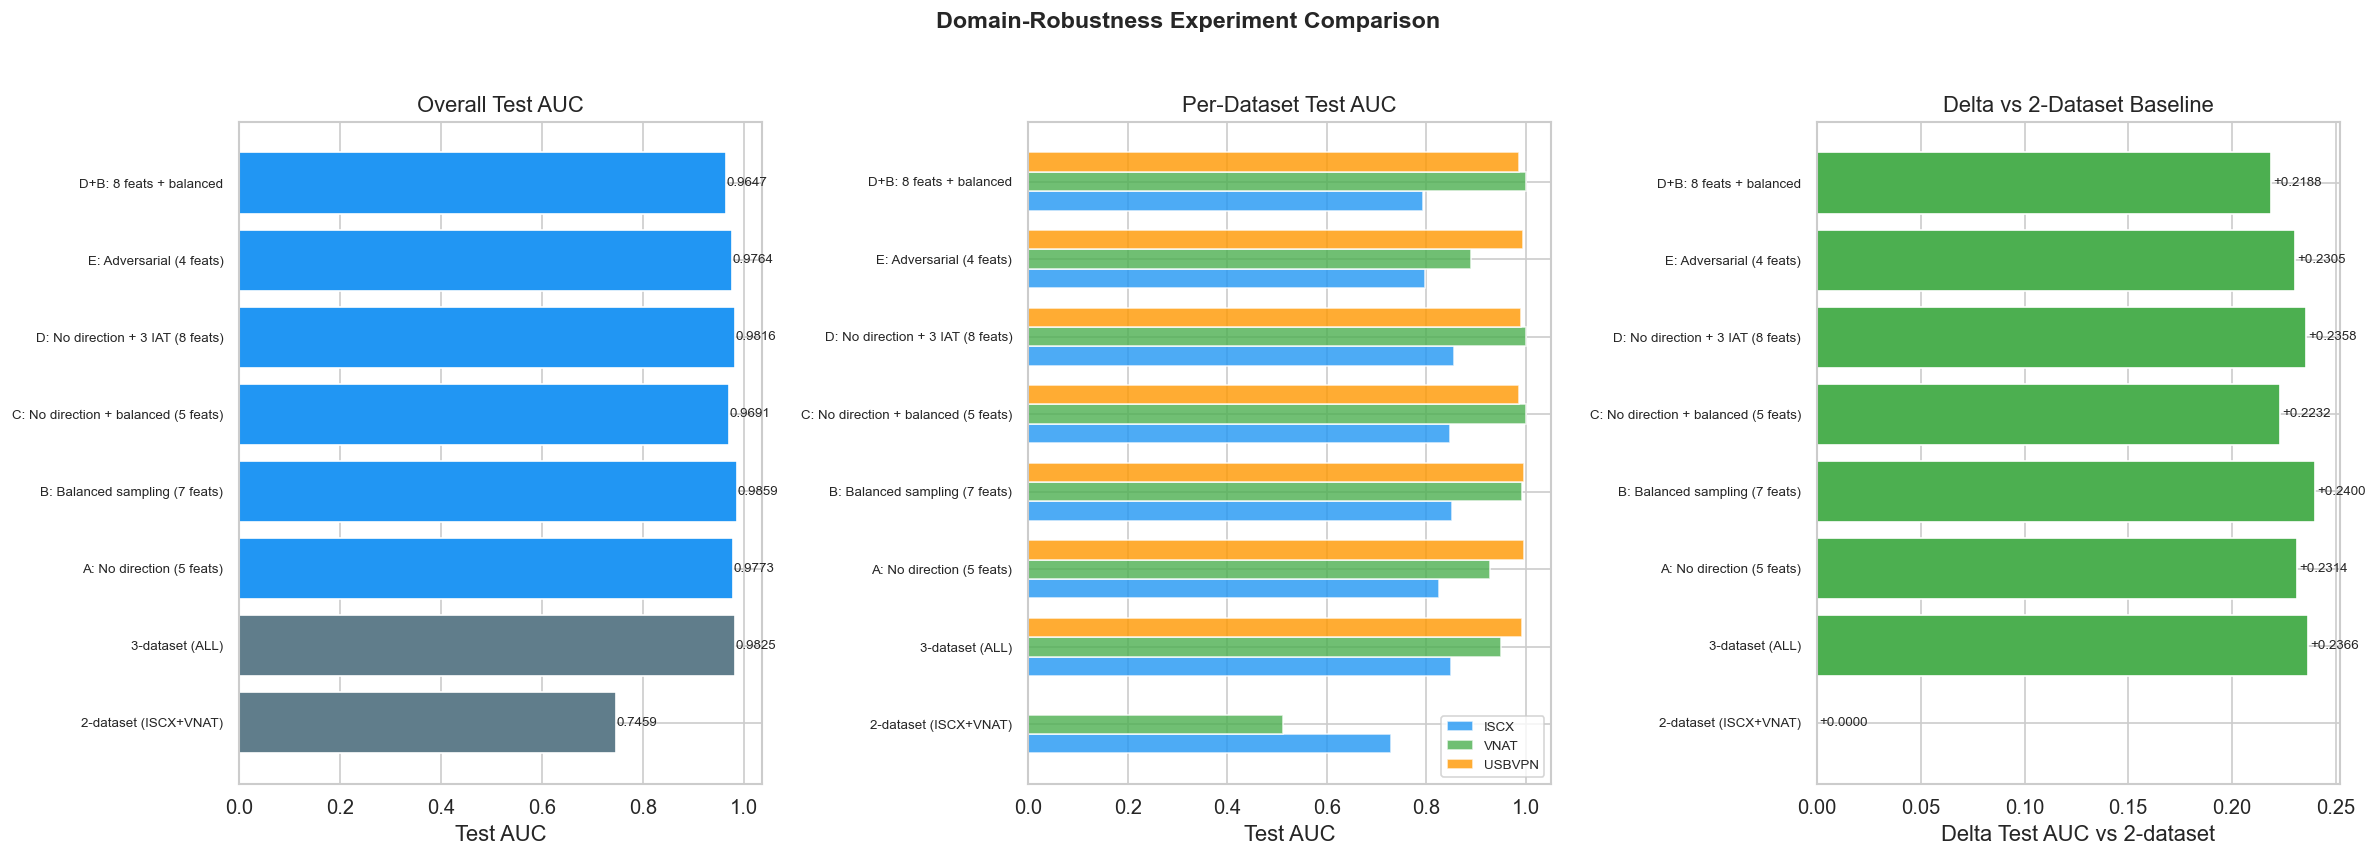

In [18]:
# ── Cell 17: Comparison visualization ──────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Prepare data
exp_names = compare_display['experiment'].tolist()
short_names = [n.replace('Baseline: ', '').replace('Exp ', '') for n in exp_names]
x = np.arange(len(short_names))

# Plot 1: Overall test AUC
ax = axes[0]
if 'test_auc' in compare_display:
    vals = compare_display['test_auc'].values
    colors = ['#607D8B' if 'Baseline' in n or 'dataset' in n else '#2196F3' for n in exp_names]
    ax.barh(x, vals, color=colors)
    ax.set_yticks(x); ax.set_yticklabels(short_names, fontsize=8)
    ax.set_xlabel('Test AUC')
    ax.set_title('Overall Test AUC')
    for i, v in enumerate(vals):
        if not np.isnan(v):
            ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8)

# Plot 2: Per-dataset test AUC
ax = axes[1]
ds_colors = {'iscx': '#2196F3', 'vnat': '#4CAF50', 'usbvpn': '#FF9800'}
bar_width = 0.25
for j, ds in enumerate(['iscx', 'vnat', 'usbvpn']):
    col = f'test_auc_{ds}'
    if col in compare_display:
        vals = compare_display[col].fillna(0).values
        ax.barh(x + j * bar_width, vals, bar_width,
                label=ds.upper(), color=ds_colors[ds], alpha=0.8)
ax.set_yticks(x + bar_width); ax.set_yticklabels(short_names, fontsize=8)
ax.set_xlabel('Test AUC')
ax.set_title('Per-Dataset Test AUC')
ax.legend(fontsize=8)

# Plot 3: Delta vs 2-dataset baseline
ax = axes[2]
if 'delta_test_auc_vs_2DS' in compare_display:
    deltas = compare_display['delta_test_auc_vs_2DS'].values
    colors = ['#4CAF50' if d >= 0 else '#E53935' for d in deltas]
    ax.barh(x, deltas, color=colors)
    ax.set_yticks(x); ax.set_yticklabels(short_names, fontsize=8)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Delta Test AUC vs 2-dataset')
    ax.set_title('Delta vs 2-Dataset Baseline')
    for i, v in enumerate(deltas):
        if not np.isnan(v):
            ax.text(v + 0.001 if v >= 0 else v - 0.015, i, f'{v:+.4f}', va='center', fontsize=8)

plt.suptitle('Domain-Robustness Experiment Comparison', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(EXPERIMENTS_DIR / 'experiment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


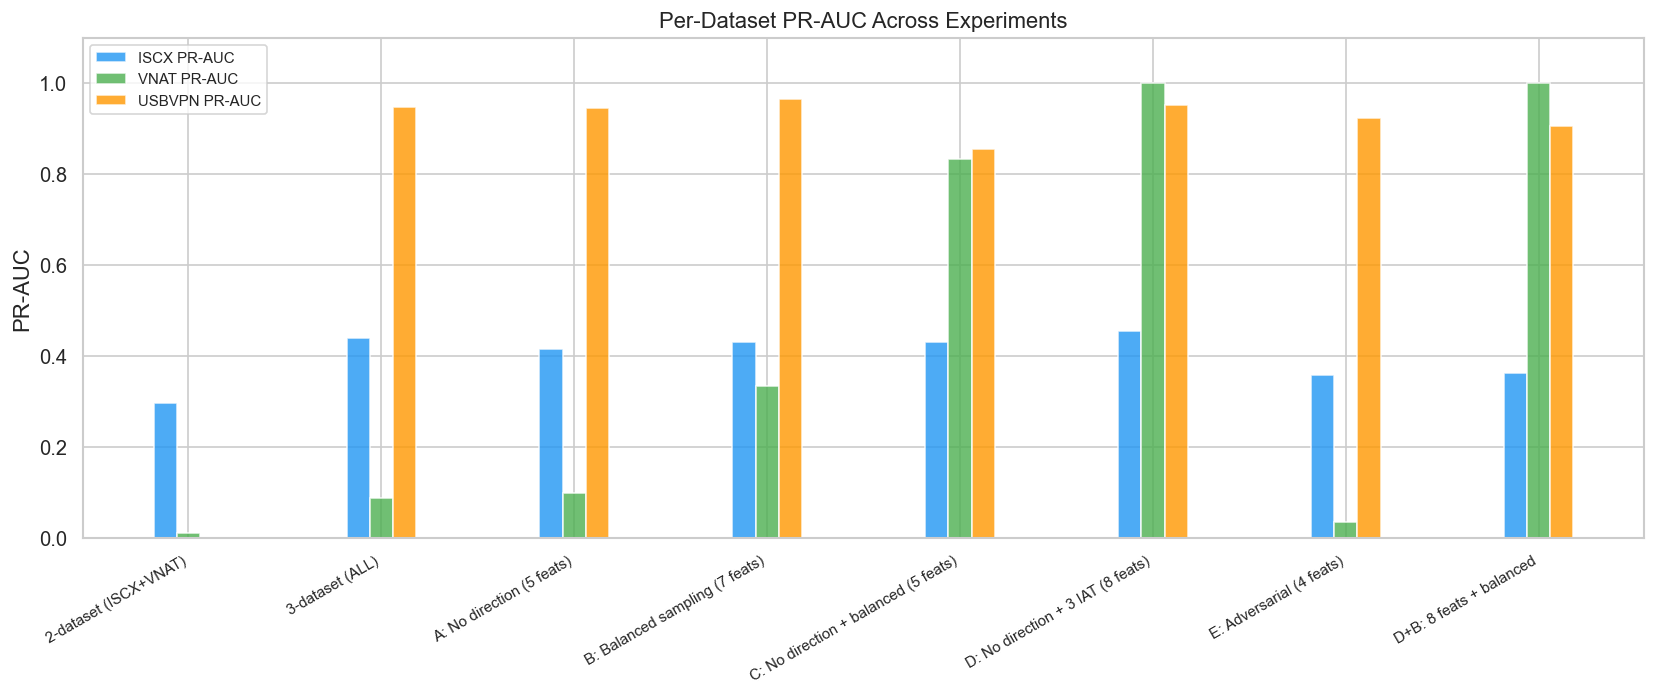

In [19]:
# ── Cell 18: Per-dataset PR-AUC comparison ─────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 6))

bar_width = 0.12
x = np.arange(len(short_names))
ds_colors = {'iscx': '#2196F3', 'vnat': '#4CAF50', 'usbvpn': '#FF9800'}

for j, (ds, color) in enumerate(ds_colors.items()):
    col = f'test_pr_auc_{ds}'
    if col in compare_df:
        vals = compare_df[col].fillna(0).values
        ax.bar(x + j * bar_width, vals, bar_width,
               label=f'{ds.upper()} PR-AUC', color=color, alpha=0.8)

ax.set_xticks(x + bar_width)
ax.set_xticklabels(short_names, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('PR-AUC')
ax.set_title('Per-Dataset PR-AUC Across Experiments')
ax.legend(fontsize=9)
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig(EXPERIMENTS_DIR / 'experiment_pr_auc.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 10 — Conclusion & Recommendation


In [20]:
# ── Cell 19: Final summary ────────────────────────────────────────────────

print('='*72)
print('  DOMAIN-ROBUSTNESS EXPERIMENT SUMMARY')
print('='*72)
print()

if len(all_summaries) >= 2:
    # Find the best 3-dataset experiment (excluding baseline_2ds)
    three_ds_exps = [s for s in all_summaries if '2-dataset' not in s.get('experiment', '')]
    if three_ds_exps:
        valid_exps = [s for s in three_ds_exps if not np.isnan(s.get('test_auc', float('nan')))]
        if valid_exps:
            best = max(valid_exps, key=lambda s: s.get('test_auc', 0))
            baseline_2ds_auc = all_summaries[0].get('test_auc', 0)
            baseline_3ds_auc = all_summaries[1].get('test_auc', 0) if len(all_summaries) > 1 else 0

            print(f'  2-Dataset Baseline Test AUC: {baseline_2ds_auc:.4f}')
            print(f'  3-Dataset Baseline Test AUC: {baseline_3ds_auc:.4f} (degraded)')
            print(f'  Best 3-Dataset Experiment:   {best["experiment"]}')
            print(f'    Test AUC: {best.get("test_auc", 0):.4f} (delta vs 2DS: {best.get("test_auc", 0) - baseline_2ds_auc:+.4f})')
            print(f'    N Features: {best.get("n_features", "?")}')
            print(f'    Features: {best.get("features", "?")}')
            print()

            for ds in ['iscx', 'vnat', 'usbvpn']:
                v = best.get(f'test_auc_{ds}', float('nan'))
                b = all_summaries[0].get(f'test_auc_{ds}', float('nan'))
                delta = v - b if not (np.isnan(v) or np.isnan(b)) else float('nan')
                print(f'    {ds:>6s}: AUC={v:.4f}  (delta vs 2DS: {delta:+.4f})')

            print()
            if best.get('test_auc', 0) >= baseline_2ds_auc * 0.99:
                print('  RECOMMENDATION: This 3-dataset config matches or exceeds 2-dataset performance.')
                print('    Consider adopting it for broader domain coverage.')
            elif best.get('test_auc', 0) >= baseline_3ds_auc:
                improvement = best.get('test_auc', 0) - baseline_3ds_auc
                print(f'  PARTIAL SUCCESS: Improved +{improvement:.4f} AUC over naive 3-dataset.')
                print('    But still below 2-dataset baseline. Consider keeping 2-dataset for production.')
            else:
                print('  No 3-dataset configuration matched the 2-dataset baseline.')
                print('    Recommendation: Keep 2-dataset (ISCX+VNAT) for production deployment.')

# Save full results
full_results = {
    'experiments': all_summaries,
    'diagnostic': {
        'domain_auc_all_7': diag_results[0]['Domain AUC'],
        'domain_auc_no_direction': diag_results[1]['Domain AUC'],
        'domain_auc_direction_only': diag_results[2]['Domain AUC'],
    },
}
with open(EXPERIMENTS_DIR / 'full_experiment_results.json', 'w') as f:
    json.dump(full_results, f, indent=2, default=str)

print(f'\nFull results saved to: {EXPERIMENTS_DIR}')
print('='*72)


  DOMAIN-ROBUSTNESS EXPERIMENT SUMMARY

  2-Dataset Baseline Test AUC: 0.7459
  3-Dataset Baseline Test AUC: 0.9825 (degraded)
  Best 3-Dataset Experiment:   Exp B: Balanced sampling (7 feats)
    Test AUC: 0.9859 (delta vs 2DS: +0.2400)
    N Features: 7
    Features: ['sz_coef_variation', 'sz_p25_median_ratio', 'sz_p75_median_ratio', 'sz_iqr_norm_median', 'dispersion_symmetry', 'direction_balance_bytes', 'direction_balance_packets']

      iscx: AUC=0.8504  (delta vs 2DS: +0.1222)
      vnat: AUC=0.9926  (delta vs 2DS: +0.4814)
    usbvpn: AUC=0.9954  (delta vs 2DS: +nan)

  RECOMMENDATION: This 3-dataset config matches or exceeds 2-dataset performance.
    Consider adopting it for broader domain coverage.

Full results saved to: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\experiments
